In [96]:
import handcalcs.render
import forallpeople as si
import colors
import matplotlib.pyplot as plt
from math import sin, cos, radians, atan, degrees 
import numpy as np
from anastruct import SystemElements
si.environment('structural', top_level=True)

# Gerberjev nosilec

Določi zunanje sile, ki uravnotežijo konstrukcijo in izračunaj vezne sile v členkih za podan lomljen Gerberven nosilec.

![lomljen Gerberjev nosilec](slike/Vaja7_lomljen_Gerberjev_nosilec.png)

Nosilec razdelimo na dve prosti telesi in za vsako zapišemo ravnotežne enačbe:

Prvo prosto telo:
$$X_A + H_c - Q_2h = 0 \tag{1}$$
$$Y_A - V_c -F + Q_2v = 0 \tag{2}$$
$$3*H_c + 6*V_c - M + 2*F - 2.5*Q_2 = 0 \tag{3}$$ 

Drugo prosto telo:
$$X_B - H_c - Q_1 = 0 \tag{4}$$
$$Y_B + V_c = 0 \tag{5}$$
$$4*H_c - 2*V_c + 2*Q_1 \tag{6}$$

Za sistem linenarnih enačb zapišemo matriko koeficientov $A$ in vektor konstant $b$ in izračunamo neznanke. 

Stolpci matrike ustrezajo naslednjemu zaporedu: $X_A, Y_A, X_B, Y_B, H_c, V_c$  

In [6]:
alpha = np.arctan(3/4)

q_1 = 10 
q_2 = 5 
F = 10 
M = 20 

Q_1 = q_1 * 4   # zvezno obtežbo pretvorimo v koncentrirano silo
Q_2 = q_2 * 5   # zvezno obtežbo pretvorimo v koncentrirano silo
Q_2h = Q_2 * np.sin(alpha)  # horizontalna komponenta
Q_2v = Q_2 * np.cos(alpha)  # vertikalna komponenta

A = [[1, 0, 0, 0, 1, 0], 
     [0, 1, 0, 0, 0, -1],
     [0, 0, 0, 0, 3, 6],
     [0, 0, 1, 0, -1, 0],
     [0, 0, 0, 1, 0, 1],
     [0, 0, 0, 0, 4, -2]
    ]
b = [Q_2h, F-Q_2v, M-2*F+2.5*Q_2, Q_1, 0, -2*Q_1]

det = np.linalg.det(A)

In [14]:
%%render param 2
det # determinanta matrike A

<IPython.core.display.Latex object>

In [8]:
X_A, Y_A, X_B, Y_B, H_c, V_c = np.linalg.solve(A, b)

In [9]:
%%render params 3
X_A
Y_A
X_B
Y_B
H_c
V_c

<IPython.core.display.Latex object>

### Preizkus ravnovesja celotne konstrukcije


In [13]:
%%render
H_i = X_A_A + X_B - Q_2h - Q_1
V_i = Y_A + Y_B - F + Q_2v

M_ic = 6*Y_A - 3*X_A - 4*X_B - 2*Y_B - M -4*F + 1.5*Q_2h + 4*Q_2v + 2*Q_1

<IPython.core.display.Latex object>

### Izračun notranjih statičnih količin vzdolž nosilca

#### Telo I: odsek A-F ($0\leq x \leq 2.5$)
(do sile F so pogoji odvisni le od zvezne obtežbe q_2)

Iz ravnotežnih enačb izračunamo osno silo, prečno silo ter upogibni moment v kateremkoli prerezu $x$.

In [64]:
%%render
x = 2 # x postavimo kjerkoli na odseku
N_x = -X_A*cos(alpha) - Y_A*sin(alpha)
V_x = -X_A*sin(alpha) + Y_A*cos(alpha) + 5*x
M_x = (-X_A*sin(alpha) + Y_A*cos(alpha))*x + 5*x**2/2

<IPython.core.display.Latex object>

Izračunajmo lokacijo in velikost ekstremnega momenta na odseku A-F. Lokacija ekstrema $M(x)$ se nahaja v točki, kjer je $V(x)=0$. 

In [92]:
%%render
x_maxM = (X_A*sin(alpha) - Y_A*cos(alpha)) / 5

<IPython.core.display.Latex object>

Velikost največjega upogibnega momenta znaša: 

In [94]:
%%render
M_max = (-X_A*sin(alpha) + Y_A*cos(alpha))*x_maxM + 5*x_maxM**2/2

<IPython.core.display.Latex object>

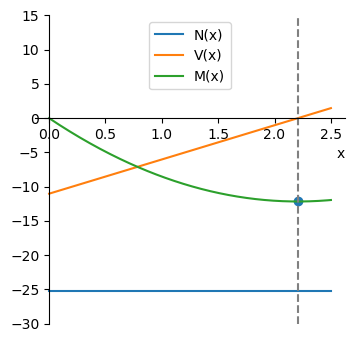

In [95]:
def NSK(x):
    N_x = -X_A*np.cos(alpha) - Y_A*np.sin(alpha)
    V_x = -X_A*np.sin(alpha) + Y_A*np.cos(alpha) + 5*x
    M_x = (-X_A*np.sin(alpha) + Y_A*np.cos(alpha))*x + 5*x**2/2
    return N_x*np.ones(len(x)), V_x, M_x

x = np.linspace(0, 2.5, 251)  # x povečujemo po centimetrih med 0 in 250 cm

N, V, M = NSK(x)

fig, ax = plt.subplots(figsize=(4,4))
ax.plot(x, N, label='N(x)')
ax.plot(x, V, label='V(x)')
ax.plot(x, M, label='M(x)')
ax.scatter(x_maxM, M_max)
ax.axvline(x=x_maxM, linestyle='--', color='gray')
ax.legend(loc='upper center')
ax.set_xlabel('x', loc='right')
ax.set_ylim(-30, 15)
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False);


#### Telo I: odsek F-M ($2.5\leq x \leq 5$)

Iz ravnotežnih enačb izračunamo osno silo, prečno silo ter upogibni moment v kateremkoli prerezu $x$.

In [61]:
%%render
x = 3
N_x = -X_A*cos(alpha) - Y_A*sin(alpha) + F*sin(alpha)
V_x = -X_A*sin(alpha) + Y_A*cos(alpha) - F * cos(alpha) +  5*x
M_x = (-X_A*sin(alpha) + Y_A*cos(alpha))*x - F*cos(alpha)*(x-2.5) + 5*x**2/2

<IPython.core.display.Latex object>

Izračunamo $M(x)$ ter $V(x)$ na začetku in koncu odseka.

In [71]:
%%render
x = 2.5
V_z = -X_A*sin(alpha) + Y_A*cos(alpha) - F * cos(alpha) +  5*x
M_z = (-X_A*sin(alpha) + Y_A*cos(alpha))*x - F*cos(alpha)*(x-2.5) + 5*x**2/2

<IPython.core.display.Latex object>

In [70]:
%%render
x = 5.0
V_k = -X_A*sin(alpha) + Y_A*cos(alpha) - F * cos(alpha) +  5*x
M_k = (-X_A*sin(alpha) + Y_A*cos(alpha))*x - F*cos(alpha)*(x-2.5) + 5*x**2/2

<IPython.core.display.Latex object>

Izračunajmo lokacijo in velikost ekstremnega momenta na odseku F-M. Lokacija ekstrema 
 se nahaja v točki, kjer je $V(x)=0$.

In [66]:
%%render
x_maxM = (X_A*sin(alpha) - Y_A*cos(alpha) + F * cos(alpha)) / 5

<IPython.core.display.Latex object>

Velikost največjega upogibnega momenta znaša:

In [75]:
%%render
M_max = (-X_A*sin(alpha) + Y_A*cos(alpha))*x_maxM - F*cos(alpha)*(x_maxM-2.5) + 5*x_maxM**2/2

<IPython.core.display.Latex object>

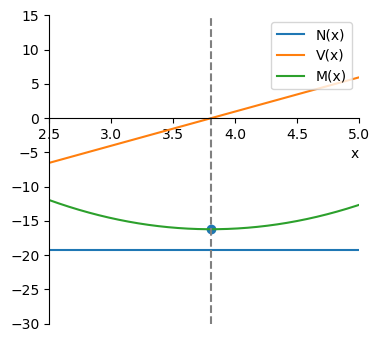

In [89]:
def NSK(x):
    N_x = -X_A*cos(alpha) - Y_A*sin(alpha) + F*sin(alpha)
    V_x = -X_A*sin(alpha) + Y_A*cos(alpha) - F * cos(alpha) +  5*x
    M_x = (-X_A*sin(alpha) + Y_A*cos(alpha))*x - F*cos(alpha)*(x-2.5) + 5*x**2/2
    return N_x*np.ones(len(x)), V_x, M_x

x = np.linspace(2.5, 5, 251)  # x povečujemo po centimetrih med 0 in 250 cm

N, V, M = NSK(x)

fig, ax = plt.subplots(figsize=(4,4))
ax.plot(x, N, label='N(x)')
ax.plot(x, V, label='V(x)')
ax.plot(x, M, label='M(x)')
ax.scatter(x_maxM, M_max)
ax.axvline(x=x_maxM, linestyle='--', color='gray')
ax.legend(loc='upper right')
ax.set_xlabel('x', loc='right')
ax.set_xlim(2.5, 5)
ax.set_ylim(-30, 15)
ax.spines[['bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False);

In [158]:
F

10

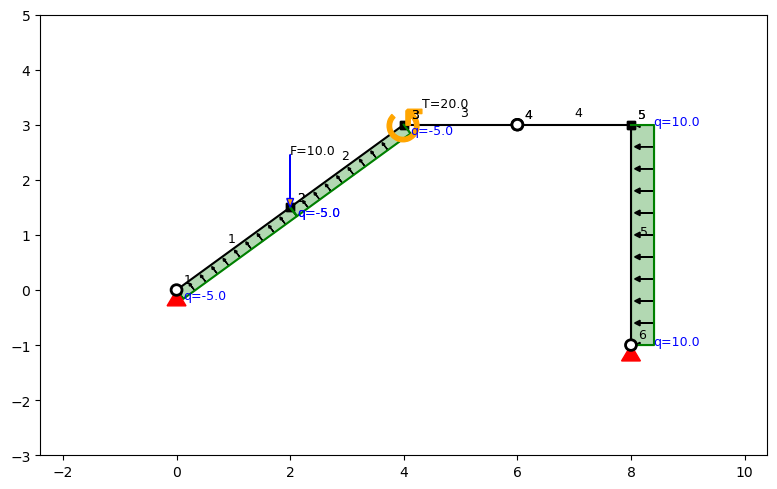

In [160]:
ss = SystemElements(figsize=(8,5))

#ss.add_truss_element(location=[[0, 0], [4, 3]])
ss.add_element(location=[[0, 0], [2, 1.5]], spring={1:0})
ss.add_element(location=[[2, 1.5], [4, 3]])
ss.add_element(location=[[4, 3], [6, 3]], spring={2:0})
ss.add_element(location=[[6, 3], [8, 3]], spring={1:0})
ss.add_element(location=[[8, 3], [8, -1]], spring={2:0})

ss.add_support_hinged(node_id=1)
ss.add_support_hinged(node_id=6)

#ss.point_load(6, Fx=0, Fy=F)
ss.q_load(q=5, element_id=1, direction='element')
ss.q_load(q=5, element_id=2, direction='element')
ss.q_load(q=-10, element_id=5, direction='element')
ss.moment_load(3, 20)
ss.point_load(2, Fy=F, rotation=180)
ss.show_structure(scale=0.8, annotations=True)
res = ss.solve()

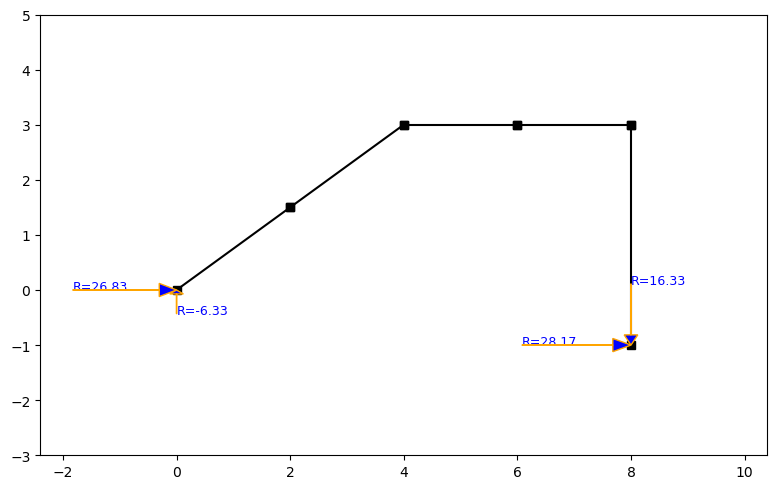

In [161]:
ss.show_reaction_force(scale=0.8)

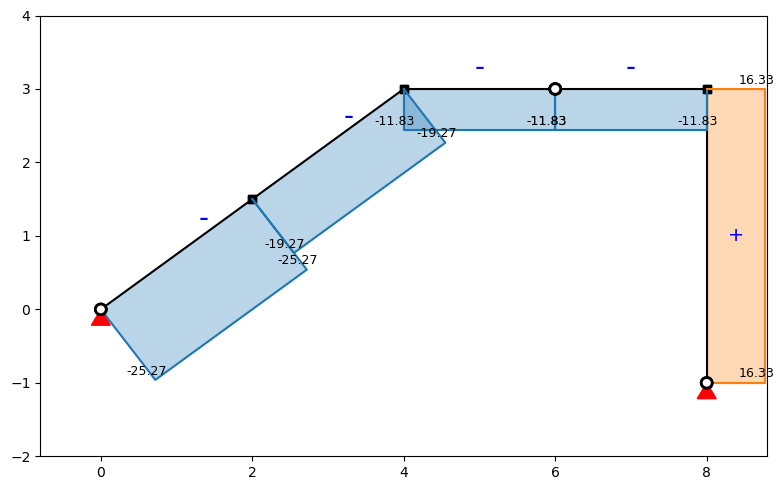

In [162]:
ss.show_axial_force(scale=0.6)

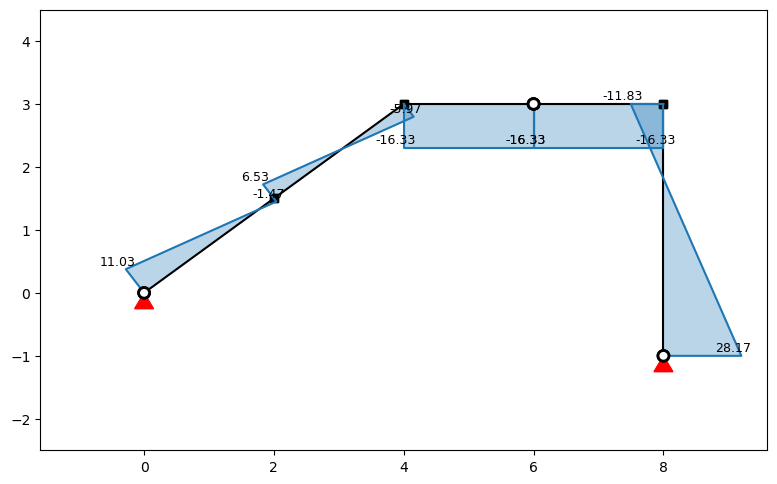

In [165]:
ss.show_shear_force(scale=0.7)

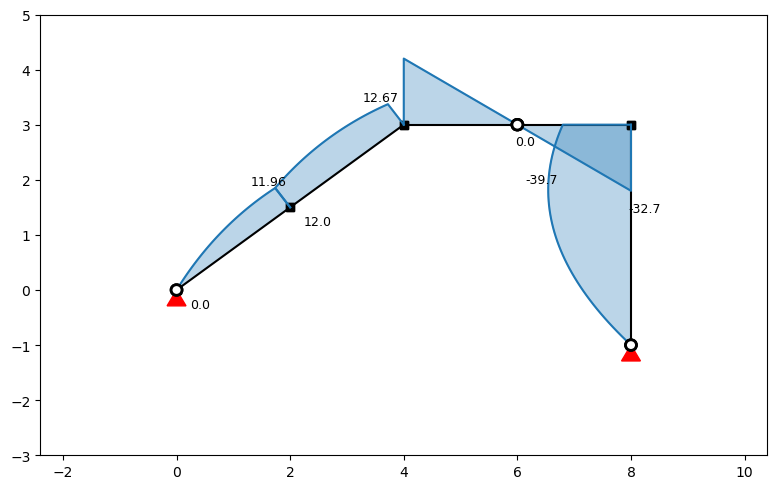

In [166]:
ss.show_bending_moment(scale=0.8)